In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid1_firefox_onscreen.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid2_firefox_onscreen.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid3_firefox_onscreen.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/odroid4_firefox_onscreen.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-4a_chrome_onscreen.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8a_chrome_onscreen.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8b_chrome_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8c_chrome_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/onscreen/rpi-8d_chrome_onscreen.csv")

In [4]:
df = pd.concat([odroid1[:2000], odroid2[:2000], odroid3[:2000], odroid4[:2000], rpi4a[:2000], rpi8a[:2000], rpi8b[:2000], rpi8c[:2000], rpi8d[:2000]])
df = df.sample(frac=1, random_state=29).reset_index(drop=True)
np.random.seed(29)

In [19]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid2,186.0,10.0,150.0,350.0,167.0,167.0,166.0
1,rpi-4a,16.2,17.4,1446.0,17.8,435.5,17.1,19.3
2,odroid1,165.0,167.0,167.0,168.0,169.0,166.0,168.0
3,odroid4,169.0,175.0,176.0,174.0,174.0,173.0,173.0
4,rpi-8c,24.9,629.1,16.7,2092.1,16.1,17.3,17.6


In [20]:
len(df)

18000

# Whats the optimal amount of training data?

In [21]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 13000, 1000):
    train_data = df.head(i)
    test_data = df.tail(5000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels\ag-20250324_043213"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       49.45 GB / 63.72 GB (77.6%)
Disk Space Avail:   942.51 GB / 1906.98 GB (49.4%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250324_043213"
Train Data Rows:    1000
Train Data Columns: 7
Label Column:       label
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	9 unique label values:  ['odroid2', 'rpi-4a', 'odroid1', 'odroid4', 'rpi-8c', 'odroid3', 'rpi-8a', 'rpi-8d', 'rpi-8b']
	If 'multiclass' is not the correct problem_type, please manually specify the

[1000]	valid_set's multi_error: 0.123333


	0.8767	 = Validation score   (accuracy)
	30.51s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8917	 = Validation score   (accuracy)
	16.57s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8717	 = Validation score   (accuracy)
	0.54s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8683	 = Validation score   (accuracy)
	0.53s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8633	 = Validation score   (accur

[1000]	valid_set's multi_error: 0.123333


	0.8789	 = Validation score   (accuracy)
	39.76s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8933	 = Validation score   (accuracy)
	27.22s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8922	 = Validation score   (accuracy)
	0.54s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8911	 = Validation score   (accuracy)
	0.56s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8789	 = Validation score   (accur

...

	0.879	 = Validation score   (accuracy)
	39.89s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.882	 = Validation score   (accuracy)
	24.85s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.871	 = Validation score   (accuracy)
	0.57s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.872	 = Validation score   (accuracy)
	0.57s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.868	 = Validation score   (accuracy)


[1000]	valid_set's multi_error: 0.114545


	0.8891	 = Validation score   (accuracy)
	56.8s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8982	 = Validation score   (accuracy)
	27.01s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.8891	 = Validation score   (accuracy)
	0.58s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.8845	 = Validation score   (accuracy)
	0.61s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8845	 = Validation score   (accura

[1000]	valid_set's multi_error: 0.116667


	0.8858	 = Validation score   (accuracy)
	39.14s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.9058	 = Validation score   (accuracy)
	23.56s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.89	 = Validation score   (accuracy)
	0.58s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.9	 = Validation score   (accuracy)
	0.59s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not, please try 'pip uninstall numpy -y; pip install numpy>=1.17.0' Detailed info: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Fitting model: ExtraTreesGini ...
	0.8925	 = Validation score   (accuracy)


In [22]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.812087,0.8116,0.810909
1,2000,0.802737,0.7994,0.798217
2,3000,0.857995,0.8588,0.857644
3,4000,0.861333,0.8616,0.860628
4,5000,0.871487,0.8718,0.870951
5,6000,0.878928,0.8796,0.878787
6,7000,0.876821,0.8778,0.877038
7,8000,0.883026,0.8840,0.883117
8,9000,0.884496,0.8854,0.884604
9,10000,0.886704,0.8874,0.886675


<Axes: xlabel='data_amount', ylabel='value'>

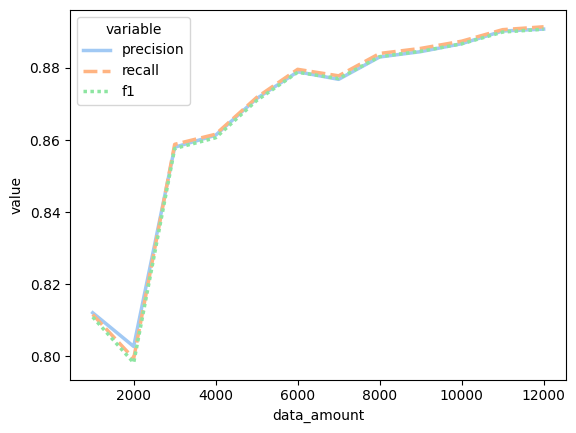

In [23]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [24]:
best_model

{'RandomForestEntr': 8,
 'RandomForestGini': 7,
 'LightGBM': 9,
 'ExtraTreesGini': 1,
 'ExtraTreesEntr': 1,
 'LightGBMLarge': 8,
 'XGBoost': 2}

([<matplotlib.patches.Wedge at 0x1b6df2b9f50>,
 [Text(0.8426488596463491, 0.7070664037675015, 'RandomForestEntr'),
  Text(-0.4648801634046089, 0.9969385305388213, 'RandomForestGini'),
  Text(-1.0625183310459778, -0.28470124023486504, 'LightGBM'),
  Text(-0.4648799890943261, -0.9969386118210386, 'ExtraTreesGini'),
  Text(-0.28470037470372794, -1.0625185629642229, 'ExtraTreesEntr'),
  Text(0.5500003659264656, -0.9526277328950455, 'LightGBMLarge'),
  Text(1.0832885683736377, -0.1910127682407498, 'XGBoost')],
 [Text(0.45962665071619035, 0.38567258387318265, '22%'),
  Text(-0.25357099822069573, 0.5437846530211752, '19%'),
  Text(-0.579555453297806, -0.15529158558265366, '25%'),
  Text(-0.2535709031423597, -0.54378469735693, '3%'),
  Text(-0.15529111347476068, -0.5795555797986669, '3%'),
  Text(0.3000001995962539, -0.5196151270336611, '22%'),
  Text(0.5908846736583478, -0.1041887826767726, '6%')])

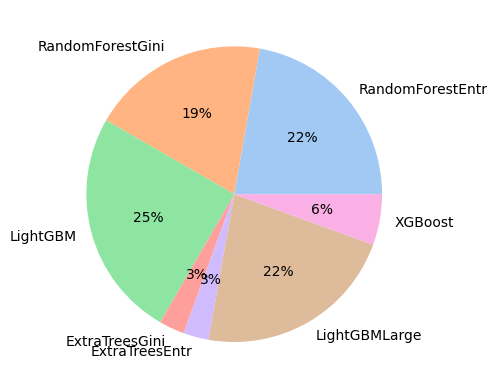

In [25]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [26]:
best_features

{'Feature 1': 11,
 'Feature 2': 12,
 'Feature 3': 7,
 'Feature 6': 3,
 'Feature 0': 3}

([<matplotlib.patches.Wedge at 0x1b6c542a010>,
 [Text(0.6309340917215729, 0.9010672405006599, 'Feature 1'),
  Text(-1.0832885061337203, 0.19101312122095906, 'Feature 2'),
  Text(-0.09587076231926031, -1.0958142164310172, 'Feature 3'),
  Text(0.7778177173879477, -0.7778172012223713, 'Feature 6'),
  Text(1.0625184735920314, -0.28470070824579974, 'Feature 0')],
 [Text(0.34414586821176696, 0.491491222091269, '31%'),
  Text(-0.5908846397093019, 0.10418897521143221, '33%'),
  Text(-0.05229314308323289, -0.5977168453260092, '19%'),
  Text(0.4242642094843351, -0.42426392793947526, '8%'),
  Text(0.5795555310501989, -0.15529129540679984, '8%')])

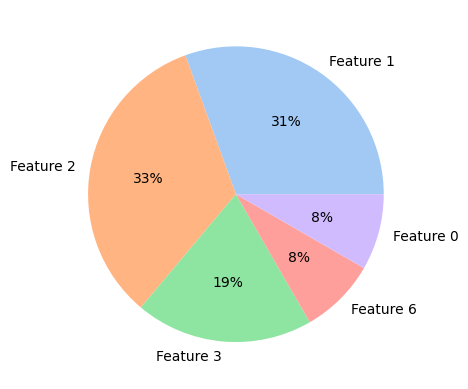

In [27]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')

In [28]:
feature_importance

,importance,stddev,p_value,n,p99_high,p99_low
Feature 2,0.16328,0.002579,7.468086e-09,5,0.168590,0.157970
Feature 1,0.09692,0.002279,3.663338e-08,5,0.101612,0.092228
Feature 3,0.09432,0.002394,4.977433e-08,5,0.099250,0.089390
Feature 4,0.08268,0.002052,4.551970e-08,5,0.086906,0.078454
Feature 6,0.07004,0.003612,8.459525e-07,5,0.077478,0.062602
Feature 0,0.06356,0.002238,1.841013e-07,5,0.068168,0.058952
Feature 5,0.05280,0.001288,4.251254e-08,5,0.055453,0.050147


In [20]:
train_data = df.head(6000)
test_data = df.tail(12000)

predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='good_quality', fit_weighted_ensemble=False)

No path specified. Models will be saved in: "AutogluonModels\ag-20250324_070258"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       46.08 GB / 63.72 GB (72.3%)
Disk Space Avail:   918.62 GB / 1906.98 GB (48.2%)
Presets specified: ['good_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DyStack is enabled (dynamic_stacking=True). AutoGluon

In [21]:
y_pred = predictor.predict(test_data)
y_pred_proba = predictor.predict_proba(test_data)
results = predictor.evaluate(test_data, detailed_report=True)

c:\Users\zac\miniconda3\envs\iot_gpu\Lib\site-packages\autogluon\core\metrics\classification_metrics.py:306: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  valid_indexes = np.logical_and(np.in1d(solution, labels), np.in1d(prediction, labels))


In [22]:
results

{'accuracy': 0.8879166666666667,
 'balanced_accuracy': np.float64(0.888399148287447),
 'mcc': np.float64(0.8739736396126839),
 'confusion_matrix':          odroid1  odroid2  odroid3  odroid4  rpi-4a  rpi-8a  rpi-8b  rpi-8c  \
 odroid1     1269        0       70        0       0       0       0       1   
 odroid2        3     1306       13        1       0       0       1       0   
 odroid3       42        9     1272        7       0       0       2       3   
 odroid4        0       11        6     1300       0       0       2       1   
 rpi-4a         0        0        0        0    1205       0      10      61   
 rpi-8a         0        0        0        0       0    1207     100       4   
 rpi-8b         0        0        0        0       0     155    1174       4   
 rpi-8c         0        0        0        0     102      11      17     932   
 rpi-8d         0        0        0        0     121       3      10     242   
 
          rpi-8d  
 odroid1       0  
 odroid2      

In [23]:
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM_BAG_L2,0.888667,accuracy,1.726573,489.497734,0.013967,8.329349,2,False,13
1,XGBoost_BAG_L2,0.887667,accuracy,1.737861,509.474589,0.025256,28.306204,2,False,18
2,NeuralNetFastAI_BAG_L2,0.887500,accuracy,1.762919,503.156238,0.050313,21.987853,2,False,11
3,LightGBMLarge_BAG_L2,0.884500,accuracy,1.782720,515.712213,0.070114,34.543828,2,False,20
4,LightGBMXT_BAG_L2,0.883667,accuracy,1.778135,486.584634,0.065529,5.416249,2,False,12
5,ExtraTreesEntr_BAG_L2,0.883333,accuracy,1.862915,481.675094,0.150309,0.506709,2,False,17
6,RandomForestEntr_BAG_L2,0.882333,accuracy,1.846835,481.886041,0.134230,0.717656,2,False,15
7,ExtraTreesGini_BAG_L2,0.882333,accuracy,1.850882,481.697579,0.138277,0.529194,2,False,16
8,LightGBM_BAG_L1,0.881833,accuracy,0.177172,2.836687,0.177172,2.836687,1,False,3
9,LightGBMLarge_BAG_L1,0.880500,accuracy,0.327665,7.864974,0.327665,7.864974,1,False,10


In [24]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = predictor.clone_for_deployment(path='classification')

Cloned TabularPredictor located in 'c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\AutogluonModels\ag-20250324_070258' to 'classification'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="classification")
Clone: Keeping minimum set of models required to predict with best model 'LightGBM_BAG_L2_FULL'...
Deleting model NeuralNetFastAI_BAG_L1. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\classification\models\NeuralNetFastAI_BAG_L1 will be removed.
Deleting model LightGBMXT_BAG_L1. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\classification\models\LightGBMXT_BAG_L1 will be removed.
Deleting model LightGBM_BAG_L1. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnApart\classification\models\LightGBM_BAG_L1 will be removed.
Deleting model RandomForestGini_BAG_L1. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 1 - DrawnAp

In [25]:
predictor_clone_opt = TabularPredictor.load(path='classification')

In [26]:
predictor_clone_opt.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM_BAG_L2_FULL,0.887917,None,accuracy,1.339449,NaN,149.632472,0.029086,NaN,0.909134,2,True,11
1,LightGBM_BAG_L1_FULL,0.884167,None,accuracy,0.083227,NaN,5.887729,0.083227,NaN,5.887729,1,True,3
2,LightGBMLarge_BAG_L1_FULL,0.883167,None,accuracy,0.242444,NaN,65.630248,0.242444,NaN,65.630248,1,True,10
3,XGBoost_BAG_L1_FULL,0.880833,None,accuracy,0.131818,NaN,3.716704,0.131818,NaN,3.716704,1,True,8
4,RandomForestEntr_BAG_L1_FULL,0.879333,None,accuracy,0.108636,0.124601,0.576303,0.108636,0.124601,0.576303,1,True,5
5,RandomForestGini_BAG_L1_FULL,0.878583,None,accuracy,0.124369,0.115395,0.606596,0.124369,0.115395,0.606596,1,True,4
6,LightGBMXT_BAG_L1_FULL,0.871833,None,accuracy,0.294399,NaN,18.671204,0.294399,NaN,18.671204,1,True,2
7,ExtraTreesEntr_BAG_L1_FULL,0.855500,None,accuracy,0.088850,0.114048,0.499978,0.088850,0.114048,0.499978,1,True,7
8,ExtraTreesGini_BAG_L1_FULL,0.845000,None,accuracy,0.092021,0.113997,0.486660,0.092021,0.113997,0.486660,1,True,6
9,NeuralNetTorch_BAG_L1_FULL,0.840083,None,accuracy,0.068812,NaN,50.027759,0.068812,NaN,50.027759,1,True,9


In [27]:
# with ensemble size was 450mb, accuracy was only 1.2% better...
size_original = predictor.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  702196222 bytes
Size Optimized: 246991678 bytes
Optimized predictor achieved a 64.8% reduction in disk usage.
